# Manual Analysis of Agency Performance

In [1]:
# This notebook was created to examine insurance agency performance.
# It uses data from Kaggle.
# The goal is to do some analyses manually and then create a ReAct bot that can duplicate the human
# work, but more quickly.
# This is the notebook for manual calculations.
# Here is an explanation of the columns: https://www.kaggle.com/code/zainawan27/exploratorydataanalysisinsurance
# Created Oct 2, 2025

In [1]:
import pandas as pd

In [2]:
# Import data
filename = '~/Documents/Software/DevFile/Property&CasualtyInsurance/agency_performance_final.csv'
pdf_data = pd.read_csv(filename)
print(pdf_data.shape)
pdf_data

(213328, 50)


,AGENCY_ID,PRIMARY_AGENCY_ID,PROD_ABBR,PROD_LINE,STATE_ABBR,STAT_PROFILE_DATE_YEAR,RETENTION_POLY_QTY,POLY_INFORCE_QTY,PREV_POLY_INFORCE_QTY,NB_WRTN_PREM_AMT,...,PL_QUO_CT_ELINKS,PL_BOUND_CT_PLRANK,PL_QUO_CT_PLRANK,PL_BOUND_CT_eQTte,PL_QUO_CT_eQTte,PL_BOUND_CT_APPLIED,PL_QUO_CT_APPLIED,PL_BOUND_CT_TRANSACTNOW,PL_QUO_CT_TRANSACTNOW,state_agency
0,3.0,3.0,BOILERMACH,CL,IN,2005,0,0.0,0.0,40.00,...,0.0,0.0,103.0,50.0,288.0,0.0,0.0,0.0,0.0,IN0003.0
1,3.0,3.0,BOILERMACH,CL,IN,2006,0,0.0,0.0,151.00,...,0.0,0.0,103.0,50.0,288.0,0.0,0.0,0.0,0.0,IN0003.0
2,3.0,3.0,BOILERMACH,CL,IN,2007,0,0.0,0.0,40.00,...,0.0,0.0,103.0,50.0,288.0,0.0,0.0,0.0,0.0,IN0003.0
3,3.0,3.0,BOILERMACH,CL,IN,2008,0,0.0,0.0,69.00,...,0.0,0.0,103.0,50.0,288.0,0.0,0.0,0.0,0.0,IN0003.0
4,3.0,3.0,BOILERMACH,CL,IN,2009,0,0.0,0.0,28.00,...,0.0,0.0,103.0,50.0,288.0,0.0,0.0,0.0,0.0,IN0003.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213323,NaN,NaN,PERSUMBREL,PL,IN,2014,39,39.0,60.0,0.00,...,0.0,0.0,0.0,22.0,136.0,0.0,0.0,0.0,0.0,IN000nan
213324,NaN,NaN,PERSUMBREL,PL,IN,2015,15,15.0,18.0,0.00,...,0.0,0.0,0.0,22.0,136.0,0.0,0.0,0.0,0.0,IN000nan
213325,NaN,NaN,PERSUMBREL,PL,KY,2013,0,9.0,NaN,132.19,...,0.0,0.0,0.0,22.0,136.0,0.0,0.0,0.0,0.0,KY000nan
213326,NaN,NaN,PERSUMBREL,PL,KY,2014,9,12.0,9.0,0.00,...,0.0,0.0,0.0,22.0,136.0,0.0,0.0,0.0,0.0,KY000nan


### Questions to investigate

1. a) How many agencies per state? b) How many policies per agency? c) How many policies were retained by agency?
2. What is the distribution of a) retention ratio, b) loss ratio, and c) growth rate?
3. How many of the top 50 most active producers are included in the top 10% of the a) retention ratio, b) loss ratio, and c) growth rate?
4. How are CL_QUO_CT_MDS and CL_QUO_CT_SBZ and CL_QUO_CT_eQT related?
5. How are PL_QUO_CT_ELINKS, PL_QUO_CT_PLRANK, PL_QUO_CT_eQTte, PL_QUO_CT_APPLIED, and
   PL_QUO_CT_TRANSACTNOW related?

In [7]:
#1a) How many agencies per state?

pdf_data.groupby('STATE_ABBR').agg(
    {'AGENCY_ID':['count','nunique']
    })

AGENCY_ID        
               count nunique
STATE_ABBR                  
IN             34751     546
KY             29266     464
MI              3691     158
OH            101307    1001
PA             32207     535
WV             11764     230

In [8]:
# 1b) How many INFORCE policies per agency?

pdf_results = pdf_data.groupby(['state_agency']).agg({
     'POLY_INFORCE_QTY':['nunique','mean','std','min','max']
    })
pdf_results.columns = pdf_results.columns.droplevel(0)  # Drop the higher-level multi-index
pdf_results = pdf_results.reset_index()
pdf_results = pdf_results.rename(columns={
    'nunique': 'n_total_policies',
    'max':     'max_total_policies'
})
pdf_results

,state_agency,n_total_policies,mean,std,min,max_total_policies
0,IN0003.0,107,488.929825,1149.518296,0.0,5137.0
1,IN000nan,59,103.418605,261.978079,0.0,1353.0
2,IN0011.0,20,6.645833,15.338276,0.0,63.0
3,IN0012.0,4,6.857143,5.520524,0.0,12.0
4,IN0148.0,41,18.136905,42.885996,0.0,194.0
...,...,...,...,...,...,...
2932,WV9608.0,2,0.071429,0.377964,0.0,2.0
2933,WV9660.0,3,0.750000,2.608514,0.0,11.0
2934,WV9733.0,1,0.000000,0.000000,0.0,0.0
2935,WV9891.0,1,0.000000,0.000000,0.0,0.0


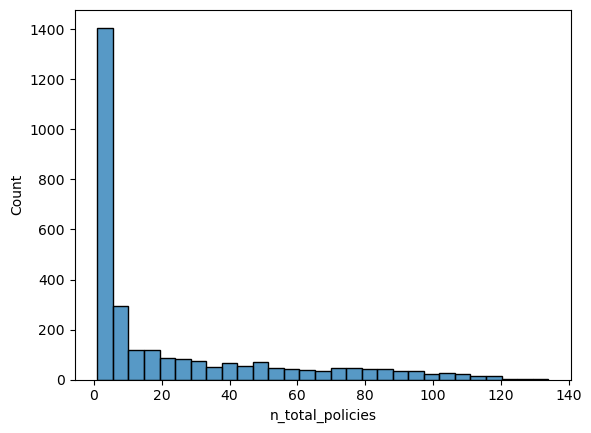

In [9]:
# Examine the distribution of the number of policies per agency
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=pdf_results, x="n_total_policies")
plt.show() # Display the plot

In [10]:
# 1c) How many policies retained by each agency?

pdf_results2 = pdf_data.groupby('state_agency').agg({
    'RETENTION_POLY_QTY':['nunique','mean','std','min','max']
})
pdf_results2.columns = pdf_results2.columns.droplevel(0)
pdf_results2 = pdf_results2.reset_index()
pdf_results2 = pdf_results2.rename(columns={
    'nunique': 'RetPol_n',
    'max':     'RetPol_max'
})
pdf_results2.sort_values(by='RetPol_n', ascending=False).head(50)

,state_agency,RetPol_n,mean,std,min,RetPol_max
2144,OH9725.0,131,1204.463415,3406.124849,0,16043
1347,OH1850.0,123,1152.406504,3209.570016,0,14624
1616,OH4351.0,121,737.565041,1870.367752,0,8199
2147,OH9733.0,121,1385.766949,3505.189657,0,15620
1221,OH0650.0,119,471.596774,1196.594692,0,5356
1214,OH0586.0,119,1480.173729,4225.304428,0,21979
1840,OH6572.0,119,833.758475,2313.332439,0,11798
2151,OH9761.0,119,1186.525424,3062.405845,0,12690
1328,OH1717.0,118,701.025210,1793.465730,0,9353
1607,OH4297.0,116,649.021459,1771.796871,0,8419


In [11]:
# Join the two result dataframes

pdf_combined_results = pd.merge(pdf_results[['state_agency','n_total_policies','max_total_policies']],\
                                pdf_results2[['state_agency','RetPol_n','RetPol_max']], \
                                on='state_agency', how='inner')
pdf_combined_results = pdf_combined_results.\
    sort_values(by=['RetPol_n','n_total_policies'], ascending=[False,False]).head(50)
pdf_combined_results

,state_agency,n_total_policies,max_total_policies,RetPol_n,RetPol_max
2144,OH9725.0,134,16789.0,131,16043
1347,OH1850.0,123,15172.0,123,14624
1616,OH4351.0,125,8627.0,121,8199
2147,OH9733.0,125,16479.0,121,15620
1840,OH6572.0,131,12402.0,119,11798
2151,OH9761.0,125,13595.0,119,12690
1214,OH0586.0,123,22968.0,119,21979
1221,OH0650.0,122,5714.0,119,5356
1328,OH1717.0,119,9771.0,118,9353
1607,OH4297.0,120,8748.0,116,8419


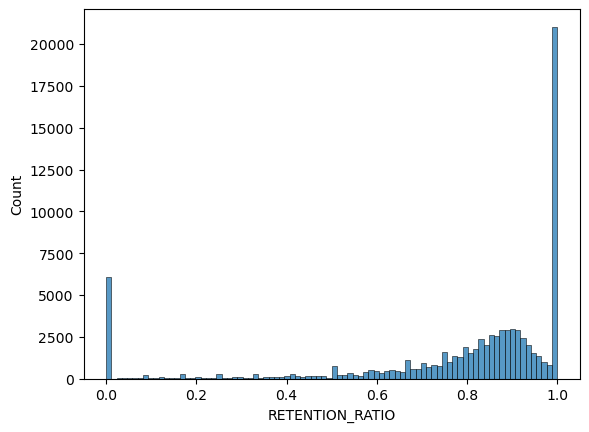

In [12]:
# 2a) Distribution of Retention Ratio

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=pdf_data, x="RETENTION_RATIO")
plt.show() # Display the plot

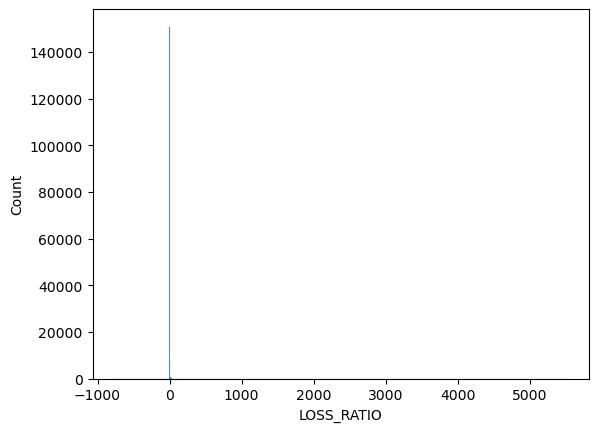

In [13]:
# 2b) Distribution of Loss Ratio

sns.histplot(data=pdf_data, x="LOSS_RATIO")
plt.show() # Display the plot

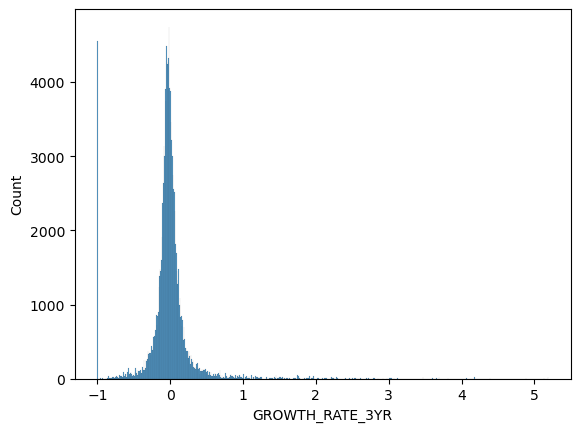

In [14]:
# 2b) Distribution of Growth Rate

sns.histplot(data=pdf_data, x="GROWTH_RATE_3YR")
plt.show() # Display the plot